In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import blimpy as bl 
import glob
%matplotlib inline

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

/datax/scratch/benjb/bliss_LSCX_test/synthetic_unresolved_vardrift1_32kHz.10_seticore.dat
Freq check: 6048.347802 versus injected 6048.3478081213025
Drift check: -0.397966 versus injected -0.4113318871158862
Freq check: 6048.379849 versus injected 6048.379857396852
Drift check: -0.530621 versus injected -0.5559170299304121
Freq check: 6048.411888 versus injected 6048.411887572516
Drift check: -0.081634 versus injected -0.075062577528763
Freq check: 6048.443865 versus injected 6048.443859654903
Drift check: 0.632664 versus injected 0.6370509814330181
Freq check: 6048.475889 versus injected 6048.475889187693
Drift check: 0.112247 versus injected 0.10886132911154456
turboSETI factor 7.522440526998506
low-drift factor 3.8776666278447203
1465
/datax/scratch/benjb/bliss_LSCX_test/synthetic_unresolved_vardrift1_32kHz_nosig_nosk_SNR_30_L1_10.dat
Freq check: 6048.347811 versus injected 6048.3478081213025
Drift check: -0.418374 versus injected -0.4113318871158862
Freq check: 6048.379858 versus i

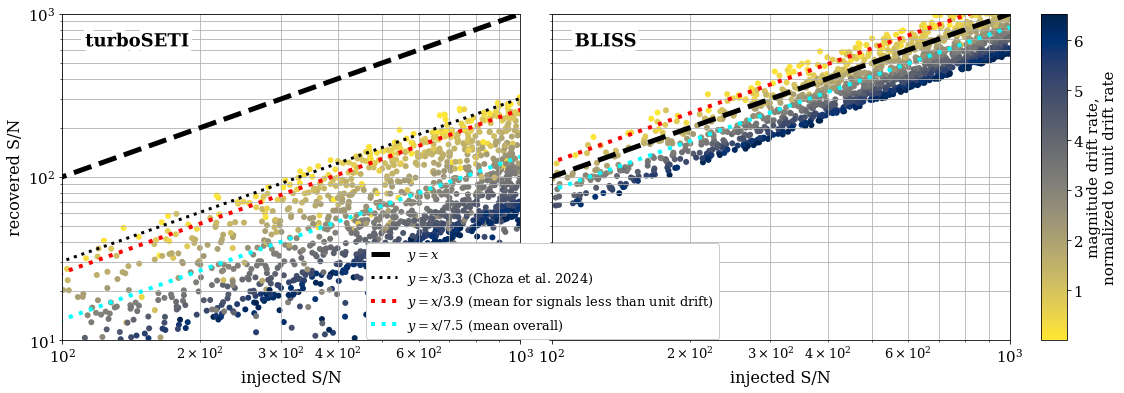

In [9]:
turboseti_snr_list = [5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,40,50,75,100,125,150,200]

turboseti_average_factor_vec = []
turboseti_low_drift_factor_vec = []

snrs = []
fps = []
tps = []
fns = []
precisions = []
recalls = []

#a = np.load(f'/datax/scratch/benjb/bliss_LSCX_test/injections_freq_DR_snr_widths_MESSIER081_0057.npy')
#a = np.load(f'/datax/scratch/benjb/bliss_LSCX_test/quick_test/widths_to_10_injections_freq_DR_snr_widths_MESSIER031_0057.npy')
#a = np.load('/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_fdsw.npy')
#a = np.load('/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_unresolved_evenmorespace.npy')
a = np.load('/datax/scratch/benjb/bliss_LSCX_test/synthetic_unresolved_vardrift1_32kHz_injections.npy')
pfreqs = a[0]
drifts = a[1]
snrvec = a[2]
widths = a[3]
snrvec1 = snrvec[np.where(widths == 1)[0]]
drifts1 = drifts[np.where(widths == 1)[0]]

f_errors = []
d_errors = []

fig, ax = plt.subplots(1,3,figsize=(18,6),gridspec_kw={'width_ratios': [18,18, 1]})

for snr in turboseti_snr_list:
    snr = 30

    recorded_snrvec = []

    #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/seticore_output/L-band/spliced_blc4041424344454647_guppi_58885_63646_MESSIER081_0057.rawspec.0000.10_seticore.dat')
    #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/quick_test/widths_to_10_blc73_guppi_58832_16209_MESSIER031_0057.rawspec.0000.10_seticore.dat')
    #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_many_widths_many_drifts.20_seticore.dat')
    #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_unresolved_evenmorespace.20_seticore.dat')
    dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/synthetic_unresolved_vardrift1_32kHz.10_seticore.dat')

    dat = dats[0]
    print(dat)

    snrs.append(snr)

    df = pd.read_table(dat, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                'Full_number_of_hits'], skiprows=9)
    ff = df['freq_start'].values
    dd = df['Drift_Rate'].values
    ss = df['SNR'].values
    n_inj = len(pfreqs)

    for i in range(n_inj):
        pf = pfreqs[i]
        pdiffvec = ff - pf
        d = drifts[i]
        #if widths[i] != 1:
        #    recorded_snrvec.append(np.nan)
        #    continue
        best_candidate_idxs = np.where(np.abs(pdiffvec)*1000 < 1)[0]
        #print('SNR', str(snr), 'best idx', str(best_candidate_idxs))
        best_candidate_drifts = np.concatenate((dd[best_candidate_idxs], [100])) # add 100 as a fix for len-0 case
        if (np.min(np.abs(pdiffvec))*1000 < 1) & (np.min(np.abs(best_candidate_drifts-d)) < 0.5): # permit accuracy to within 1 kHz
            #print(best_candidate_drifts)
            f_errors.append(ff[np.argmin(np.abs(pdiffvec))]-pf)
            d_errors.append(best_candidate_drifts[np.argmin(np.abs(best_candidate_drifts-d))]-d)
            if i < 5:
                print(f'Freq check: {ff[np.argmin(np.abs(pdiffvec))]} versus injected {pf}')
                print(f'Drift check: {best_candidate_drifts[np.argmin(np.abs(best_candidate_drifts-d))]} versus injected {d}')
            true_idx = best_candidate_idxs[np.argmin(np.abs(best_candidate_drifts-d))]
            recorded_snr = ss[true_idx]
            recorded_snrvec.append(recorded_snr)
        else:
            recorded_snrvec.append(np.nan)
        #break

    s = ax[0].scatter(snrvec, np.array(recorded_snrvec), c=np.abs(drifts)/0.153, cmap='cividis_r', alpha=1, lw=0, marker='o')
    turboseti_average_factor_vec.append(1/np.average(np.nan_to_num(np.array(recorded_snrvec))[~np.isnan(recorded_snrvec)]/snrvec[~np.isnan(recorded_snrvec)]))
    dtrunc_recorded_snrvec = np.array(recorded_snrvec)[np.where(np.abs(drifts)<0.153)[0]]
    dtrunc_snrvec = snrvec[np.where(np.abs(drifts)<0.153)[0]]
    turboseti_low_drift_factor_vec.append(1/np.average(dtrunc_recorded_snrvec[~np.isnan(dtrunc_recorded_snrvec)]/dtrunc_snrvec[~np.isnan(dtrunc_recorded_snrvec)]))
    break

print(f'turboSETI factor {np.average(turboseti_average_factor_vec)}')
print(f'low-drift factor {np.average(turboseti_low_drift_factor_vec)}')

ax[0].plot([0,1000],[0,1000], c='k', lw=5, ls='--', label=r'$y = x$')
ax[0].plot([0,1000],[0,1000/3.3], c='k', lw=3, ls=':', label=rf'$y = x/${3.3} (Choza et al. 2024)')
ax[0].plot([0,1000],[0,1000/np.average(turboseti_low_drift_factor_vec)], c='red', lw=4, ls=':', label=rf'$y = x/${np.round(np.average(turboseti_low_drift_factor_vec),1)} (mean for signals less than unit drift)')
ax[0].plot([0,1000],[0,1000/np.average(turboseti_average_factor_vec)], c='cyan', lw=4, ls=':', label=rf'$y = x/${np.round(np.average(turboseti_average_factor_vec),1)} (mean overall)')

cbar = plt.colorbar(s, cax=ax[2])
cbar.set_label(label='magnitude drift rate,\nnormalized to unit drift rate', size=15)
cbar.ax.tick_params(labelsize=15)
cbar.solids.set(alpha=1)

ax[0].set_xlabel('injected S/N', size=16)
ax[0].set_ylabel('recovered S/N', size=16)

ax[0].set_yscale('log')
ax[0].set_xscale('log')

ax[0].set_xlim(100,1000)
ax[0].set_ylim(10,1000)
ax[0].tick_params(axis='both', which='major', labelsize=15)
ax[0].tick_params(axis='both', which='minor', labelsize=13)

ax[0].grid(which='both')

#plt.savefig('/datax/scratch/benjb/bliss_LSCX_test/turboSETI_synthetic_w1_SNR_recovery.pdf', bbox_inches='tight')

bliss_snr_list = np.concatenate((np.arange(start=10, stop=36, step=5), [40, 50, 75, 100, 150, 200]))

bliss_average_factor_vec = []
bliss_low_drift_factor_vec = []

snrs = []
fps = []
tps = []
fns = []
precisions = []
recalls = []

#a = np.load(f'/datax/scratch/benjb/bliss_LSCX_test/injections_freq_DR_snr_widths_MESSIER081_0057.npy')
#a = np.load('/datax/scratch/benjb/bliss_LSCX_test/quick_test/widths_to_10_injections_freq_DR_snr_widths_MESSIER031_0057.npy')
#a = np.load('/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_fdsw.npy')
#a = np.load('/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_unresolved_evenmorespace.npy')
a = np.load('/datax/scratch/benjb/bliss_LSCX_test/synthetic_unresolved_vardrift1_32kHz_injections.npy')
pfreqs = a[0]
drifts = a[1]
snrvec = a[2]
widths = a[3]
print(len(snrvec))
snrvec1 = snrvec[np.where(widths==1)[0]]
drifts1 = drifts[np.where(widths==1)[0]]

bf_found = []
bd_found = []
bf_errors = []
bd_errors = []
bw_found = []
bw_errors = []

for snr in bliss_snr_list:
    snr = 30
    l1 = 10

    b_recorded_snrvec = []

    #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/bliss_output/spliced_blc4041424344454647_guppi_58885_63646_MESSIER081_0057.rawspec.0000_SNR_30_L1_10.dat')
    #dats = glob.glob('/home/benjb/nearby-stars/widths_to_10_blc73_guppi_58832_16209_MESSIER031_0057.rawspec.0000.dat')
    #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_many_widths_many_drifts_SNR_30_L1_10.dat')
    #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_unresolved_evenmorespace_SNR_30_L1_10.dat')
    dats = glob.glob('/datax/scratch/benjb/bliss_LSCX_test/synthetic_unresolved_vardrift1_32kHz_nosig_nosk_SNR_30_L1_10.dat')

    dat = dats[0]
    #dat = '/datax/scratch/benjb/bliss_LSCX_test/quick_test/widths_to_10_blc73_guppi_58832_16209_MESSIER031_0057.rawspec.0000_SNR_30_L1_10.dat'
    #dat = '/datax/scratch/benjb/bliss_LSCX_test/bliss_output_test/040825/spliced_blc4041424344454647_guppi_58885_63646_MESSIER081_0057.rawspec.0000_SNR_30_L1_10.dat'
    print(dat)

    snrs.append(snr)

    df = pd.read_table(dat, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                'Full_number_of_hits'], skiprows=9)
    ff = df['freq_start'].values
    dd = df['Drift_Rate'].values
    ss = df['SNR'].values
    ww = df['Full_number_of_hits'].values
    n_inj = len(pfreqs)

    for i in range(n_inj):
        pf = pfreqs[i]
        pdiffvec = ff - pf
        d = drifts[i]
        w = widths[i]
        #if snrvec[i] < 30:
        #    continue
        #if w != 1:
        #    b_recorded_snrvec.append(np.nan)
        #    continue
        best_candidate_idxs = np.where(np.abs(pdiffvec)*1000 < 1)[0]
        #print('SNR', str(snr), 'best idx', str(best_candidate_idxs))
        best_candidate_drifts = np.concatenate((dd[best_candidate_idxs], [100])) # add 100 as a fix for len-0 case
        if (np.min(np.abs(pdiffvec))*1000 < 1) & (np.min(np.abs(best_candidate_drifts-d)) < 0.5): # permit accuracy to within 2 kHz
            #print(best_candidate_drifts)
            bf_found.append(ff[np.argmin(np.abs(pdiffvec))])
            bd_found.append(best_candidate_drifts[np.argmin(np.abs(best_candidate_drifts-d))])
            bf_errors.append(ff[np.argmin(np.abs(pdiffvec))]-pf)
            bw_found.append(ww[np.argmin(np.abs(pdiffvec))])
            bw_errors.append(ww[np.argmin(np.abs(pdiffvec))]-w)
            bd_errors.append(best_candidate_drifts[np.argmin(np.abs(best_candidate_drifts-d))]-d)
            if i < 5:
                print(f'Freq check: {ff[np.argmin(np.abs(pdiffvec))]} versus injected {pf}')
                print(f'Drift check: {best_candidate_drifts[np.argmin(np.abs(best_candidate_drifts-d))]} versus injected {d}')
            true_idx = best_candidate_idxs[np.argmin(np.abs(best_candidate_drifts-d))]
            recorded_snr = ss[true_idx]
            #print('recorded SNR', str(recorded_snr))
            #print(true_idx, snrvec[2*i], recorded_snr)
            b_recorded_snrvec.append(recorded_snr)
        else:
            b_recorded_snrvec.append(np.nan)
        #break
    print(len(b_recorded_snrvec))

    #plt.plot(sr, sp, color='orangered', alpha=0.1)
    #print(snrvec[::2][:10])
    #print(recorded_snrvec[:10])
    #plt.scatter(snrvec, recorded_snrvec, color='orangered', alpha=0.1, lw=0, marker='o')
    print(len(snrvec1))
    print(len(b_recorded_snrvec))
    ax[1].scatter(snrvec, b_recorded_snrvec, c=np.abs(drifts)/0.153, cmap='cividis_r', alpha=1, lw=0, marker='o')
    #print(1/np.average(np.nan_to_num(np.array(recorded_snrvec))/snrvec[::2]))
    bliss_average_factor_vec.append(1/np.average(np.nan_to_num(np.array(b_recorded_snrvec))[~np.isnan(b_recorded_snrvec)]/snrvec[~np.isnan(b_recorded_snrvec)]))
    dtrunc_recorded_snrvec = np.array(b_recorded_snrvec)[np.where(np.abs(drifts)<0.153)[0]]
    dtrunc_snrvec = snrvec[np.where(np.abs(drifts)<0.153)[0]]
    bliss_low_drift_factor_vec.append(1/np.average(dtrunc_recorded_snrvec[~np.isnan(dtrunc_recorded_snrvec)]/dtrunc_snrvec[~np.isnan(dtrunc_recorded_snrvec)]))
    break

print(f'BLISS factor {np.average(bliss_average_factor_vec)}')

ax[1].plot([0,1000],[0,1000], c='k', lw=5, ls='--', label=r'$y = x$')
#plt.plot([0,1000],[0,1000/3.3], c='darkorange', lw=4, ls=':', label=rf'$y = x/${3.3} (Choza et al. 2024)')
ax[1].plot([0,1000],[0,1000/np.average(bliss_low_drift_factor_vec)], c='red', lw=4, ls=':', label=rf'$y = x/${np.round(np.average(bliss_low_drift_factor_vec),1)} (mean for hits less than unit drift)')
ax[1].plot([0,1000],[0,1000/np.average(bliss_average_factor_vec)], c='cyan', lw=4, ls=':', label=rf'$y = x/${np.round(np.average(bliss_average_factor_vec),1)} (mean overall)')

# cbar = plt.colorbar()
# cbar.set_label(label=r'magnitude drift rate normalized to unit drift rate', size=13)
# cbar.solids.set(alpha=1)

#plt.errorbar(x=sr_avgvec, y=sp_avgvec, yerr=sp_errvec, xerr=sr_errvec, marker='o', color='orangered',
#             ecolor='k', capsize=2, elinewidth=1, label='turboSETI: variable SNR, variable drift')

ax[1].set_xlabel('injected S/N', size=16)
#ax[1].set_ylabel('recovered SNR', size=15)

ax[1].set_yscale('log')
ax[1].set_xscale('log')

ax[1].set_xlim(100,1000)
ax[1].set_ylim(10,1000)
ax[1].tick_params(axis='both', which='major', labelsize=15)
ax[1].tick_params(axis='both', which='minor', labelsize=13)
ax[1].set_yticklabels([])

handles, labels = ax[0].get_legend_handles_labels()
ax[1].legend(handles, labels, loc='center', bbox_to_anchor=[-0.02, 0.15], fontsize=13, framealpha=1)
#ax[1].legend(loc='lower left', fontsize=12)
ax[1].grid(which='both')

import matplotlib.patheffects as pe

ax[0].text(0.05,0.90,'turboSETI', weight='bold', size=18, transform=ax[0].transAxes,
           path_effects=[pe.withStroke(linewidth=10, foreground="white")])
ax[1].text(0.05,0.90,'BLISS', weight='bold', size=18, transform=ax[1].transAxes, 
           path_effects=[pe.withStroke(linewidth=10, foreground="white")])

#plt.xlim(0,1)
#plt.ylim(0,1)
plt.subplots_adjust(wspace=0.1)
#plt.savefig('/datax/scratch/benjb/bliss_LSCX_test/Fig_both_algs_synthetic_w1_SNR_recovery.pdf', bbox_inches='tight')
plt.show()

0.004999999999199645
/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_fdsw_morespace.20_seticore.dat
Freq check: 8418.462044 versus injected 8418.462034043967
Drift check: 0.07143 versus injected 0.12931791924230063
Freq check: 8418.467039 versus injected 8418.467034043966
Drift check: 0.55103 versus injected 0.5517397672857056
Freq check: 8418.472029 versus injected 8418.472034043965
Drift check: 0.14286 versus injected 0.10667189609935779
Freq check: 8418.477036 versus injected 8418.477034043965
Drift check: -0.0 versus injected -0.013098369557495548
Freq check: 8418.48204 versus injected 8418.482034043964
Drift check: 0.81634 versus injected 0.8150679273974681
turboSETI factor 3.325039476349556
low-drift factor 3.055084548604029


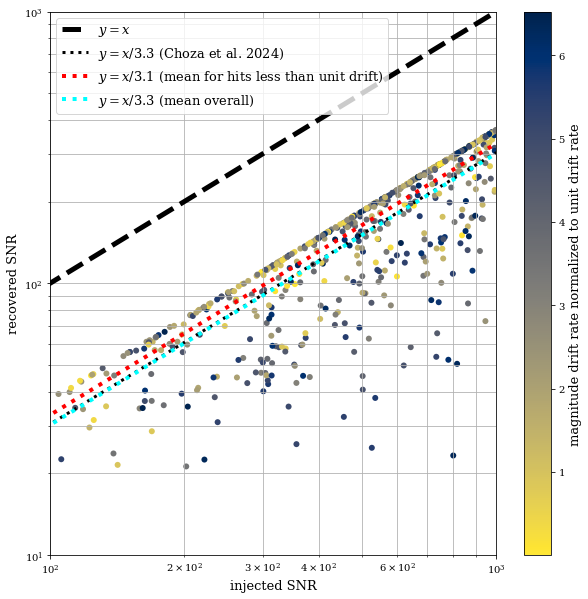

In [40]:
turboseti_snr_list = [5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,40,50,75,100,125,150,200]

turboseti_average_factor_vec = []
turboseti_low_drift_factor_vec = []

snrs = []
fps = []
tps = []
fns = []
precisions = []
recalls = []

#a = np.load(f'/datax/scratch/benjb/bliss_LSCX_test/injections_freq_DR_snr_widths_MESSIER081_0057.npy')
#a = np.load(f'/datax/scratch/benjb/bliss_LSCX_test/quick_test/widths_to_10_injections_freq_DR_snr_widths_MESSIER031_0057.npy')
#a = np.load('/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_fdsw.npy')
#a = np.load('/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_unresolved_evenmorespace.npy')
#a = np.load('/datax/scratch/benjb/bliss_LSCX_test/synthetic_unresolved_vardrift1_32kHz_injections.npy')
#a = np.load('/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_fdsw_evenmorespace.npy') # sinc2
a = np.load('/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_fdsw_morespace.npy')
pfreqs = a[0]
print(pfreqs[1]-pfreqs[0])
drifts = a[1]
snrvec = a[2]
widths = a[3]
snrvec1 = snrvec[np.where(widths == 1)[0]]
drifts1 = drifts[np.where(widths == 1)[0]]

f_errors = []
d_errors = []

fig, ax = plt.subplots(1,1,figsize=(10,10))

for snr in turboseti_snr_list:
    snr = 30

    recorded_snrvec = []

    #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/seticore_output/L-band/spliced_blc4041424344454647_guppi_58885_63646_MESSIER081_0057.rawspec.0000.10_seticore.dat')
    #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/quick_test/widths_to_10_blc73_guppi_58832_16209_MESSIER031_0057.rawspec.0000.10_seticore.dat')
    #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_many_widths_many_drifts.20_seticore.dat')
    dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_unresolved_evenmorespace.20_seticore.dat')
    #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/synthetic_unresolved_vardrift1_32kHz.10_seticore.dat')
    dats = glob.glob('/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_fdsw_evenmorespace.20_seticore.dat')
    dats = glob.glob('/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_fdsw_morespace.20_seticore.dat')

    dat = dats[0]
    print(dat)

    snrs.append(snr)

    df = pd.read_table(dat, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                'Full_number_of_hits'], skiprows=9)
    ff = df['freq_start'].values
    dd = df['Drift_Rate'].values
    ss = df['SNR'].values
    n_inj = len(pfreqs)

    for i in range(n_inj):
        pf = pfreqs[i]
        pdiffvec = ff - pf
        d = drifts[i]
        #if widths[i] != 1:
        #    recorded_snrvec.append(np.nan)
        #    continue
        best_candidate_idxs = np.where(np.abs(pdiffvec)*1000 < 1)[0]
        #print('SNR', str(snr), 'best idx', str(best_candidate_idxs))
        best_candidate_drifts = np.concatenate((dd[best_candidate_idxs], [100])) # add 100 as a fix for len-0 case
        if (np.min(np.abs(pdiffvec))*1000 < 1) & (np.min(np.abs(best_candidate_drifts-d)) < 0.5): # permit accuracy to within 1 kHz
            #print(best_candidate_drifts)
            f_errors.append(ff[np.argmin(np.abs(pdiffvec))]-pf)
            d_errors.append(best_candidate_drifts[np.argmin(np.abs(best_candidate_drifts-d))]-d)
            if i < 5:
                print(f'Freq check: {ff[np.argmin(np.abs(pdiffvec))]} versus injected {pf}')
                print(f'Drift check: {best_candidate_drifts[np.argmin(np.abs(best_candidate_drifts-d))]} versus injected {d}')
            true_idx = best_candidate_idxs[np.argmin(np.abs(best_candidate_drifts-d))]
            recorded_snr = ss[true_idx]
            recorded_snrvec.append(recorded_snr)
        else:
            recorded_snrvec.append(np.nan)
        #break

    plt.scatter(snrvec, np.array(recorded_snrvec), c=np.abs(drifts)/0.153, cmap='cividis_r', alpha=1, lw=0, marker='o')
    turboseti_average_factor_vec.append(1/np.average(np.nan_to_num(np.array(recorded_snrvec))[~np.isnan(recorded_snrvec)]/snrvec[~np.isnan(recorded_snrvec)]))
    dtrunc_recorded_snrvec = np.array(recorded_snrvec)[np.where(np.abs(drifts)<0.153)[0]]
    dtrunc_snrvec = snrvec[np.where(np.abs(drifts)<0.153)[0]]
    turboseti_low_drift_factor_vec.append(1/np.average(dtrunc_recorded_snrvec[~np.isnan(dtrunc_recorded_snrvec)]/dtrunc_snrvec[~np.isnan(dtrunc_recorded_snrvec)]))
    break

print(f'turboSETI factor {np.average(turboseti_average_factor_vec)}')
print(f'low-drift factor {np.average(turboseti_low_drift_factor_vec)}')

plt.plot([0,1000],[0,1000], c='k', lw=5, ls='--', label=r'$y = x$')
plt.plot([0,1000],[0,1000/3.3], c='k', lw=3, ls=':', label=rf'$y = x/${3.3} (Choza et al. 2024)')
plt.plot([0,1000],[0,1000/np.average(turboseti_low_drift_factor_vec)], c='red', lw=4, ls=':', label=rf'$y = x/${np.round(np.average(turboseti_low_drift_factor_vec),1)} (mean for hits less than unit drift)')
plt.plot([0,1000],[0,1000/np.average(turboseti_average_factor_vec)], c='cyan', lw=4, ls=':', label=rf'$y = x/${np.round(np.average(turboseti_average_factor_vec),1)} (mean overall)')

cbar = plt.colorbar()
cbar.set_label(label=r'magnitude drift rate normalized to unit drift rate', size=13)
cbar.solids.set(alpha=1)

plt.xlabel('injected SNR', size=13)
plt.ylabel('recovered SNR', size=13)

plt.yscale('log')
plt.xscale('log')

plt.xlim(100,1000)
plt.ylim(10,1000)

plt.legend(loc='upper left', fontsize=13)
plt.grid(which='both')

#plt.savefig('/datax/scratch/benjb/bliss_LSCX_test/turboSETI_synthetic_w1_SNR_recovery.pdf', bbox_inches='tight')
plt.show()

584
/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_fdsw_morespace_SNR_30_L1_10.dat
Freq check: 8418.462018 versus injected 8418.462034043967
Drift check: 0.234698 versus injected 0.12931791924230063
Freq check: 8418.467034 versus injected 8418.467034043966
Drift check: 0.561234 versus injected 0.5517397672857056
Freq check: 8418.472035 versus injected 8418.472034043965
Drift check: 0.122451 versus injected 0.10667189609935779
Freq check: 8418.482032 versus injected 8418.482034043964
Drift check: 0.846953 versus injected 0.8150679273974681
584
47
584
BLISS factor 0.4559244055485934


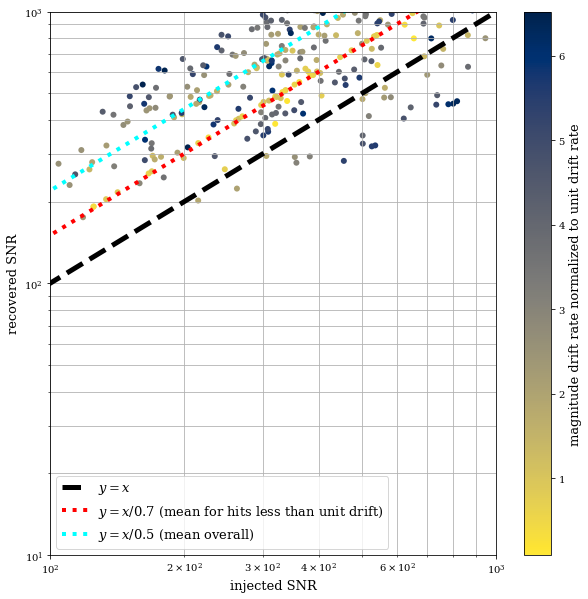

In [41]:
bliss_snr_list = np.concatenate((np.arange(start=10, stop=36, step=5), [40, 50, 75, 100, 150, 200]))

bliss_average_factor_vec = []
bliss_low_drift_factor_vec = []

snrs = []
fps = []
tps = []
fns = []
precisions = []
recalls = []

#a = np.load(f'/datax/scratch/benjb/bliss_LSCX_test/injections_freq_DR_snr_widths_MESSIER081_0057.npy')
#a = np.load('/datax/scratch/benjb/bliss_LSCX_test/quick_test/widths_to_10_injections_freq_DR_snr_widths_MESSIER031_0057.npy')
#a = np.load('/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_fdsw.npy')
#a = np.load('/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_unresolved_evenmorespace.npy')
#a = np.load('/datax/scratch/benjb/bliss_LSCX_test/synthetic_unresolved_vardrift1_32kHz_injections.npy')
a = np.load('/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_fdsw_evenmorespace.npy')
a = np.load('/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_fdsw_morespace.npy')
pfreqs = a[0]
drifts = a[1]
snrvec = a[2]
widths = a[3]
print(len(snrvec))
snrvec1 = snrvec[np.where(widths==1)[0]]
drifts1 = drifts[np.where(widths==1)[0]]

bf_found = []
bd_found = []
bf_errors = []
bd_errors = []
bw_found = []
bw_errors = []

fig, ax = plt.subplots(1,1,figsize=(10,10))

for snr in bliss_snr_list:
    snr = 30
    l1 = 10

    b_recorded_snrvec = []

    #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/bliss_output/spliced_blc4041424344454647_guppi_58885_63646_MESSIER081_0057.rawspec.0000_SNR_30_L1_10.dat')
    #dats = glob.glob('/home/benjb/nearby-stars/widths_to_10_blc73_guppi_58832_16209_MESSIER031_0057.rawspec.0000.dat')
    #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_many_widths_many_drifts_SNR_30_L1_10.dat')
    #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_unresolved_evenmorespace_SNR_30_L1_10.dat')
    #dats = glob.glob('/datax/scratch/benjb/bliss_LSCX_test/synthetic_unresolved_vardrift1_32kHz_nosig_nosk_SNR_30_L1_10.dat')
    dats = glob.glob('/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_fdsw_evenmorespace_SNR_30_L1_10.dat')
    dats = glob.glob('/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_fdsw_morespace_SNR_30_L1_10.dat')

    dat = dats[0]
    #dat = '/datax/scratch/benjb/bliss_LSCX_test/quick_test/widths_to_10_blc73_guppi_58832_16209_MESSIER031_0057.rawspec.0000_SNR_30_L1_10.dat'
    #dat = '/datax/scratch/benjb/bliss_LSCX_test/bliss_output_test/040825/spliced_blc4041424344454647_guppi_58885_63646_MESSIER081_0057.rawspec.0000_SNR_30_L1_10.dat'
    print(dat)

    snrs.append(snr)

    df = pd.read_table(dat, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                'Full_number_of_hits'], skiprows=9)
    ff = df['freq_start'].values
    dd = df['Drift_Rate'].values
    ss = df['SNR'].values
    ww = df['Full_number_of_hits'].values
    n_inj = len(pfreqs)

    for i in range(n_inj):
        pf = pfreqs[i]
        pdiffvec = ff - pf
        d = drifts[i]
        w = widths[i]
        #if snrvec[i] < 30:
        #    continue
        #if w != 1:
        #    b_recorded_snrvec.append(np.nan)
        #    continue
        best_candidate_idxs = np.where(np.abs(pdiffvec)*1000 < 1)[0]
        #print('SNR', str(snr), 'best idx', str(best_candidate_idxs))
        best_candidate_drifts = np.concatenate((dd[best_candidate_idxs], [100])) # add 100 as a fix for len-0 case
        if (np.min(np.abs(pdiffvec))*1000 < 1) & (np.min(np.abs(best_candidate_drifts-d)) < 0.5): # permit accuracy to within 2 kHz
            #print(best_candidate_drifts)
            bf_found.append(ff[np.argmin(np.abs(pdiffvec))])
            bd_found.append(best_candidate_drifts[np.argmin(np.abs(best_candidate_drifts-d))])
            bf_errors.append(ff[np.argmin(np.abs(pdiffvec))]-pf)
            bw_found.append(ww[np.argmin(np.abs(pdiffvec))])
            bw_errors.append(ww[np.argmin(np.abs(pdiffvec))]-w)
            bd_errors.append(best_candidate_drifts[np.argmin(np.abs(best_candidate_drifts-d))]-d)
            if i < 5:
                print(f'Freq check: {ff[np.argmin(np.abs(pdiffvec))]} versus injected {pf}')
                print(f'Drift check: {best_candidate_drifts[np.argmin(np.abs(best_candidate_drifts-d))]} versus injected {d}')
            true_idx = best_candidate_idxs[np.argmin(np.abs(best_candidate_drifts-d))]
            recorded_snr = ss[true_idx]
            #print('recorded SNR', str(recorded_snr))
            #print(true_idx, snrvec[2*i], recorded_snr)
            b_recorded_snrvec.append(recorded_snr)
        else:
            b_recorded_snrvec.append(np.nan)
        #break
    print(len(b_recorded_snrvec))

    #plt.plot(sr, sp, color='orangered', alpha=0.1)
    #print(snrvec[::2][:10])
    #print(recorded_snrvec[:10])
    #plt.scatter(snrvec, recorded_snrvec, color='orangered', alpha=0.1, lw=0, marker='o')
    print(len(snrvec1))
    print(len(b_recorded_snrvec))
    plt.scatter(snrvec, b_recorded_snrvec, c=np.abs(drifts)/0.153, cmap='cividis_r', alpha=1, lw=0, marker='o')
    #print(1/np.average(np.nan_to_num(np.array(recorded_snrvec))/snrvec[::2]))
    bliss_average_factor_vec.append(1/np.average(np.nan_to_num(np.array(b_recorded_snrvec))[~np.isnan(b_recorded_snrvec)]/snrvec[~np.isnan(b_recorded_snrvec)]))
    dtrunc_recorded_snrvec = np.array(b_recorded_snrvec)[np.where(np.abs(drifts)<0.153)[0]]
    dtrunc_snrvec = snrvec[np.where(np.abs(drifts)<0.153)[0]]
    bliss_low_drift_factor_vec.append(1/np.average(dtrunc_recorded_snrvec[~np.isnan(dtrunc_recorded_snrvec)]/dtrunc_snrvec[~np.isnan(dtrunc_recorded_snrvec)]))
    break

print(f'BLISS factor {np.average(bliss_average_factor_vec)}')

plt.plot([0,1000],[0,1000], c='k', lw=5, ls='--', label=r'$y = x$')
#plt.plot([0,1000],[0,1000/3.3], c='darkorange', lw=4, ls=':', label=rf'$y = x/${3.3} (Choza et al. 2024)')
plt.plot([0,1000],[0,1000/np.average(bliss_low_drift_factor_vec)], c='red', lw=4, ls=':', label=rf'$y = x/${np.round(np.average(bliss_low_drift_factor_vec),1)} (mean for hits less than unit drift)')
plt.plot([0,1000],[0,1000/np.average(bliss_average_factor_vec)], c='cyan', lw=4, ls=':', label=rf'$y = x/${np.round(np.average(bliss_average_factor_vec),1)} (mean overall)')

cbar = plt.colorbar()
cbar.set_label(label=r'magnitude drift rate normalized to unit drift rate', size=13)
cbar.solids.set(alpha=1)

#plt.errorbar(x=sr_avgvec, y=sp_avgvec, yerr=sp_errvec, xerr=sr_errvec, marker='o', color='orangered',
#             ecolor='k', capsize=2, elinewidth=1, label='turboSETI: variable SNR, variable drift')

plt.xlabel('injected SNR', size=13)
plt.ylabel('recovered SNR', size=13)

plt.yscale('log')
plt.xscale('log')

plt.xlim(100,1000)
plt.ylim(10,1000)

plt.legend(loc='lower left', fontsize=13)
plt.grid(which='both')

#plt.xlim(0,1)
#plt.ylim(0,1)
#plt.savefig('/datax/scratch/benjb/bliss_LSCX_test/BLISS_synthetic_w1_SNR_recovery.pdf', bbox_inches='tight')
plt.show()

4.403170346226851
5.266435243957453
543
543


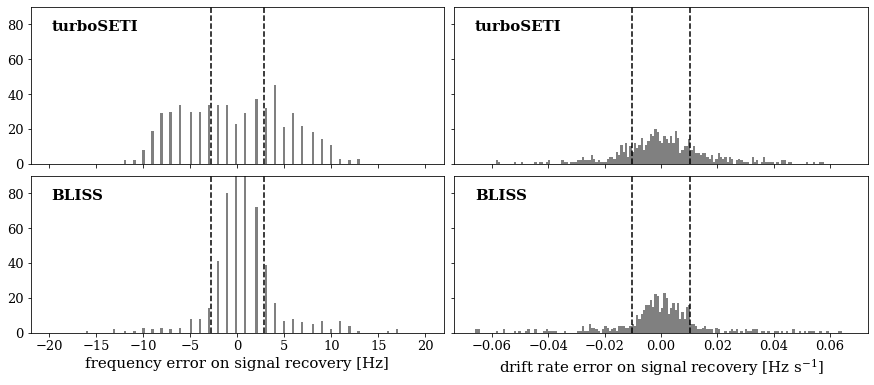

In [42]:
from scipy.stats import kurtosis 

print(kurtosis(bf_errors))
print(kurtosis(bd_errors))

print(len(bf_errors))
print(len(np.where(np.isnan(b_recorded_snrvec)==False)[0]))
fig, ax = plt.subplots(2,2,figsize=(15,6))

ax[0,0].hist(np.array(f_errors)*1000000, bins=500//3, range=(-20,20), color='grey')
ax[0,0].axvline(2.79, color='k', ls='--')
ax[0,0].axvline(-2.79, color='k', ls='--')
ax[0,0].set_xticklabels([])
#ax[0].set_yscale('log')
#ax[0,0].set_xlabel('turboSETI frequency error on signal recovery [Hz]')
#ax[0].grid()

ax[0,1].hist(np.array(d_errors), bins=500//3, range=(-0.20/3,0.20/3), color='grey')
#ax[0,1].set_xlabel(r'turboSETI drift rate error on signal recovery [Hz s$^{-1}$]')
ax[0,1].axvline(0.010204, color='k', ls='--')
ax[0,1].axvline(-0.010204, color='k', ls='--')
ax[0,1].set_xticklabels([])
ax[0,1].set_yticklabels([])
#ax[1].set_yscale('log')
#ax[1].grid()

ax[1,0].hist(np.array(bf_errors)*1000000, bins=500//3, range=(-20,20), color='grey')
ax[1,0].axvline(2.79, color='k', ls='--')
ax[1,0].axvline(-2.79, color='k', ls='--')
#ax[0].set_xlim(-100,100)
#ax[0].set_yscale('log')
ax[1,0].set_xlabel('frequency error on signal recovery [Hz]', size=15)
#ax[0].grid()

ax[1,1].hist(np.array(bd_errors), bins=500//3, range=(-0.2/3,0.2/3), color='grey')
ax[1,1].set_xlabel(r'drift rate error on signal recovery [Hz s$^{-1}$]', size=15)
ax[1,1].axvline(0.010204, color='k', ls='--')
ax[1,1].axvline(-0.010204, color='k', ls='--')
ax[1,1].set_yticklabels([])
#ax[1].set_yscale('log')
#ax[1].grid()

ax[0,0].set_ylim([0,90])
ax[1,0].set_ylim([0,90])
ax[0,1].set_ylim([0,90])
ax[1,1].set_ylim([0,90])

ax[0,0].text(0.05,0.85,'turboSETI', weight='bold', size=15, transform=ax[0,0].transAxes)
ax[0,1].text(0.05,0.85,'turboSETI', weight='bold', size=15, transform=ax[0,1].transAxes)
ax[1,0].text(0.05,0.85,'BLISS', weight='bold', size=15, transform=ax[1,0].transAxes)
ax[1,1].text(0.05,0.85,'BLISS', weight='bold', size=15, transform=ax[1,1].transAxes)

for a in ax.flatten():
    a.tick_params(axis='both', which='major', labelsize=13)

plt.subplots_adjust(hspace=0.075, wspace=0.025)
#plt.savefig('/datax/scratch/benjb/bliss_LSCX_test/Fig_both_algs_freqdrift_recovery_errors.pdf', bbox_inches='tight')
plt.show()

In [43]:
print(len(recorded_snrvec))
print(len(snrvec))

snr_ratios = np.array(recorded_snrvec)[~np.isnan(recorded_snrvec)]/snrvec[~np.isnan(recorded_snrvec)]
b_snr_ratios = np.array(b_recorded_snrvec)[~np.isnan(b_recorded_snrvec)]/snrvec[~np.isnan(b_recorded_snrvec)]

584
584


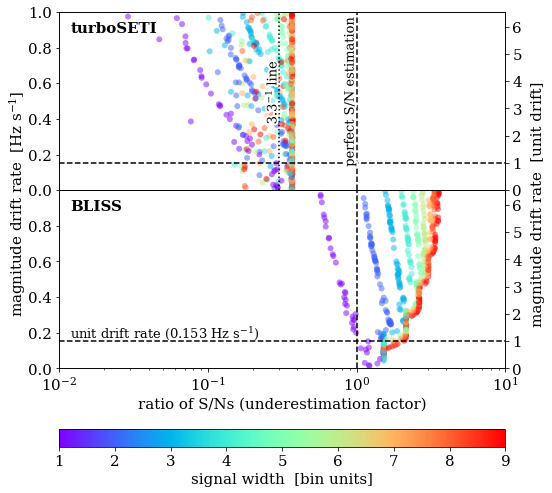

In [45]:
gs_up = plt.GridSpec(3, 1, hspace=0, height_ratios=[5,5,2.2])
gs_down = plt.GridSpec(3, 1, height_ratios=[10,10,1])
fig = plt.figure(figsize=(8,8))
ax0 = fig.add_subplot(gs_up[0,:])
ax1 = fig.add_subplot(gs_up[1,:])
ax2 = fig.add_subplot(gs_down[2,:])
ax = [ax0] + [ax1] + [ax2]

#fig, ax = plt.subplots(3,1,figsize=(10,8), gridspec_kw={'height_ratios': [5, 5, 1]})

s0 = ax[0].scatter(snr_ratios, np.abs(drifts[~np.isnan(recorded_snrvec)]), c=widths[~np.isnan(recorded_snrvec)], cmap='rainbow', alpha=0.5, lw=0)
ax[0].set_xscale('log')
#ax[0].set_xlabel('turboSETI SNR ratio (underestimation factor)')
#ax[0].set_ylabel(r'magnitude drift rate [Hz s$^{-1}$]', size=15)
ax0r = ax[0].twinx()
ax0r.set_yticks([0, 1*0.153, 2*0.153, 3*0.153, 4*0.153, 5*0.153, 6*0.153])
ax0r.set_yticklabels([0, 1, 2, 3, 4, 5, 6])
#ax0r.set_ylabel('magnitude drift rate [unit DR]')
ax[0].axhline(0.153, ls='--', color='k')
ax[0].axvline(1/3.3, ls=':', color='k')
ax[0].axvline(1, ls='--', color='k')
ax[0].text(0.025, 0.95, 'turboSETI', weight='bold', size=15, color='k', ha='left', va='top', rotation=0,
            transform=ax[0].transAxes)
ax[0].text(1, 0.55, r'perfect S/N estimation', color='k', ha='right', va='center', rotation=90, size=13,
            transform=ax[0].get_xaxis_transform(),
            path_effects=[pe.withStroke(linewidth=4, foreground="white")])
ax[0].text(1/3.3, 0.55, r'3.3$^{-1}$ line', color='k', ha='right', va='center', rotation=90, size=13,
            transform=ax[0].get_xaxis_transform(),
            path_effects=[pe.withStroke(linewidth=4, foreground="white")])
ax[0].set_xlim(0.01, 10)
ax[0].set_ylim(0, 1)
ax0r.set_ylim(0, 1)
ax[0].set_yticks([0,0.2,0.4,0.6,0.8,1.0])

s1 = ax[1].scatter(b_snr_ratios, np.abs(drifts[~np.isnan(b_recorded_snrvec)]), c=widths[~np.isnan(b_recorded_snrvec)], cmap='rainbow', alpha=0.5, lw=0)
ax[1].set_xscale('log')
ax[1].set_xlabel('ratio of S/Ns (underestimation factor)', size=15)
#ax[1].set_ylabel(r'magnitude drift rate [Hz s$^{-1}$]', size=15)
ax1r = ax[1].twinx()
ax1r.set_yticks([0, 1*0.153, 2*0.153, 3*0.153, 4*0.153, 5*0.153, 6*0.153])
ax1r.set_yticklabels([0, 1, 2, 3, 4, 5, 6])
#ax1r.set_ylabel('magnitude drift rate [unit DR]')
ax[1].axhline(0.153, ls='--', color='k')
ax[1].axvline(1, ls='--', color='k')
ax[1].text(0.025, 0.95, 'BLISS', weight='bold', size=15, color='k', ha='left', va='top', rotation=0,
            transform=ax[1].transAxes)
ax[1].text(0.025, 0.153, r'unit drift rate (0.153 Hz s$^{-1}$)', color='k', ha='left', va='bottom', rotation=0, size=13,
            transform=ax[1].get_yaxis_transform())
ax[1].set_xlim(0.01, 10)
ax[1].set_ylim(0,1)
ax1r.set_ylim(0,1)
ax[1].set_yticks([0,0.2,0.4,0.6,0.8])

fig.text(0.035, 0.5+1/21, r'magnitude drift rate  [Hz s$^{-1}$]', va='center', rotation='vertical', size=15)
fig.text(0.945, 0.5+1/21, r'magnitude drift rate  [unit drift]', va='center', rotation='vertical', size=15)

ax[0].tick_params(axis='both', which='major', labelsize=15)
ax[1].tick_params(axis='both', which='major', labelsize=15)
ax0r.tick_params(axis='both', which='major', labelsize=15)
ax1r.tick_params(axis='both', which='major', labelsize=15)

cbar = fig.colorbar(s1, cax=ax[2], orientation='horizontal')
cbar.set_label(label=r'signal width  [bin units]', size=15)
cbar.solids.set(alpha=1)
cbar.ax.tick_params(labelsize=15)

ax[0].set_xticklabels([])
#for a in ax:
#    a.set_xticklabels([])
plt.savefig('/datax/scratch/benjb/bliss_LSCX_test/Fig_both_algs_boxcar_5kHz_spacing_width_handling_comparison.pdf', bbox_inches='tight')
plt.show()

In [93]:
1/0.153

6.5359477124183005

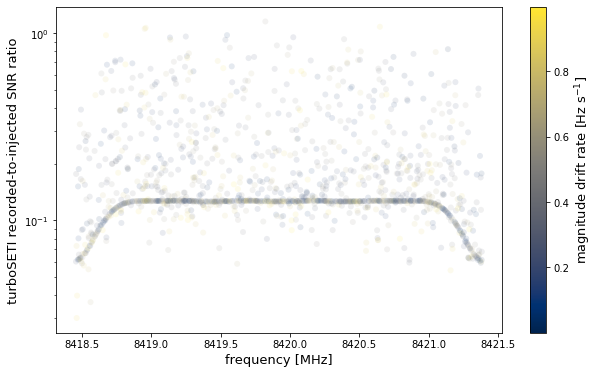

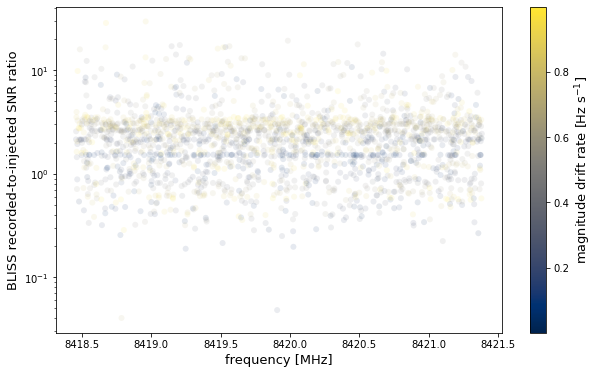

In [53]:
#print([~np.isnan(recorded_snrvec)])
snr_ratios = np.array(recorded_snrvec)[~np.isnan(recorded_snrvec)]/snrvec[~np.isnan(recorded_snrvec)]
fig,ax = plt.subplots(1,1,figsize=(10,6))
plt.scatter(pfreqs[~np.isnan(recorded_snrvec)], snr_ratios, alpha=0.1, 
            c=np.abs(drifts[~np.isnan(recorded_snrvec)]), cmap='cividis', 
            lw=0)
cbar = plt.colorbar()
cbar.set_label(label=r'magnitude drift rate [Hz s$^{-1}$]', size=13)
cbar.solids.set(alpha=1)
plt.xlabel('frequency [MHz]', size=13)
plt.ylabel('turboSETI recorded-to-injected SNR ratio', size=13)
plt.yscale('log')
plt.show()

#print([~np.isnan(recorded_snrvec)])
b_snr_ratios = np.array(b_recorded_snrvec)[~np.isnan(b_recorded_snrvec)]/snrvec[~np.isnan(b_recorded_snrvec)]
fig,ax = plt.subplots(1,1,figsize=(10,6))
plt.scatter(pfreqs[~np.isnan(b_recorded_snrvec)], b_snr_ratios, alpha=0.1, 
            c=np.abs(drifts[~np.isnan(b_recorded_snrvec)]), cmap='cividis', 
            lw=0)
cbar = plt.colorbar()
cbar.set_label(label=r'magnitude drift rate [Hz s$^{-1}$]', size=13)
cbar.solids.set(alpha=1)
plt.xlabel('frequency [MHz]', size=13)
plt.ylabel('BLISS recorded-to-injected SNR ratio', size=13)
#plt.legend()
plt.yscale('log')
plt.show()

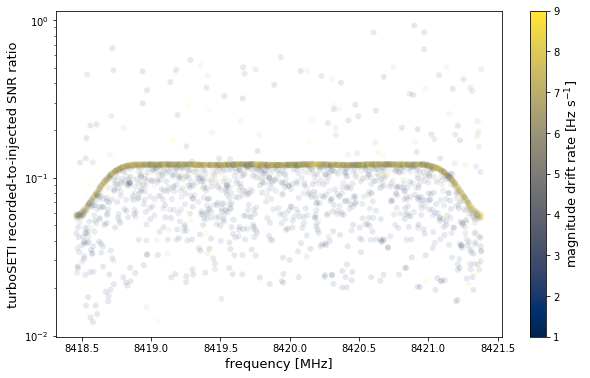

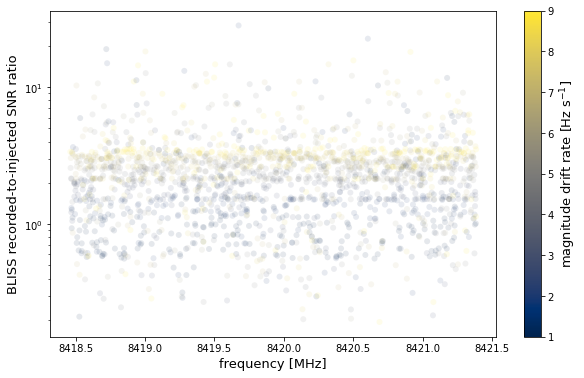

In [45]:
#print([~np.isnan(recorded_snrvec)])
snr_ratios = np.array(recorded_snrvec)[~np.isnan(recorded_snrvec)]/snrvec[~np.isnan(recorded_snrvec)]
fig,ax = plt.subplots(1,1,figsize=(10,6))
plt.scatter(pfreqs[~np.isnan(recorded_snrvec)], snr_ratios, alpha=0.1, 
            c=np.abs(widths[~np.isnan(recorded_snrvec)]), cmap='cividis', 
            lw=0)
cbar = plt.colorbar()
cbar.set_label(label=r'magnitude drift rate [Hz s$^{-1}$]', size=13)
cbar.solids.set(alpha=1)
plt.xlabel('frequency [MHz]', size=13)
plt.ylabel('turboSETI recorded-to-injected SNR ratio', size=13)
plt.yscale('log')
plt.show()

#print([~np.isnan(recorded_snrvec)])
b_snr_ratios = np.array(b_recorded_snrvec)[~np.isnan(b_recorded_snrvec)]/snrvec[~np.isnan(b_recorded_snrvec)]
fig,ax = plt.subplots(1,1,figsize=(10,6))
plt.scatter(pfreqs[~np.isnan(b_recorded_snrvec)], b_snr_ratios, alpha=0.1, 
            c=np.abs(widths[~np.isnan(b_recorded_snrvec)]), cmap='cividis', 
            lw=0)
cbar = plt.colorbar()
cbar.set_label(label=r'magnitude drift rate [Hz s$^{-1}$]', size=13)
cbar.solids.set(alpha=1)
plt.xlabel('frequency [MHz]', size=13)
plt.ylabel('BLISS recorded-to-injected SNR ratio', size=13)
#plt.legend()
plt.yscale('log')
plt.show()